![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Proyecto 2 - Clasificación de género de películas

El propósito de este proyecto es que puedan poner en práctica, en sus respectivos grupos de trabajo, sus conocimientos sobre técnicas de preprocesamiento, modelos predictivos de NLP, y la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 2: Clasificación de género de películas"

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 8. Sin embargo, es importante que avancen en la semana 7 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 8, y subir el archivo de predicciones a la [competencia de Kaggle](https://www.kaggle.com/t/29c44fce98c747f2a1dfdaf29d4c4965).

## Datos para la predicción de género en películas

![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/moviegenre.png)

En este proyecto se usará un conjunto de datos de géneros de películas. Cada observación contiene el título de una película, su año de lanzamiento, la sinopsis o plot de la película (resumen de la trama) y los géneros a los que pertenece (una película puede pertenercer a más de un género). Por ejemplo:
- Título: 'How to Be a Serial Killer'
- Plot: 'A serial killer decides to teach the secrets of his satisfying career to a video store clerk.'
- Generos: 'Comedy', 'Crime', 'Horror'

La idea es que usen estos datos para predecir la probabilidad de que una película pertenezca, dada la sinopsis, a cada uno de los géneros.

Agradecemos al profesor Fabio González, Ph.D. y a su alumno John Arevalo por proporcionar este conjunto de datos. Ver https://arxiv.org/abs/1702.01992

## Ejemplo predicción conjunto de test para envío a Kaggle
En esta sección encontrarán el formato en el que deben guardar los resultados de la predicción para que puedan subirlos a la competencia en Kaggle.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
import pandas as pd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import joblib
%matplotlib inline

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

In [3]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://github.com/albahnsen/MIAD_ML_and_NLP/raw/main/datasets/dataTraining.zip', encoding='UTF-8', index_col=0)
dataTesting = pd.read_csv('https://github.com/albahnsen/MIAD_ML_and_NLP/raw/main/datasets/dataTesting.zip', encoding='UTF-8', index_col=0)

In [4]:
# Visualización datos de entrenamiento
dataTraining.head()

,year,title,plot,genres,rating
3107,2003,Most,most is the story of a single father who takes...,"['Short', 'Drama']",8.0
900,2008,How to Be a Serial Killer,a serial killer decides to teach the secrets o...,"['Comedy', 'Crime', 'Horror']",5.6
6724,1941,A Woman's Face,"in sweden , a female blackmailer with a disfi...","['Drama', 'Film-Noir', 'Thriller']",7.2
4704,1954,Executive Suite,"in a friday afternoon in new york , the presi...",['Drama'],7.4
2582,1990,Narrow Margin,"in los angeles , the editor of a publishing h...","['Action', 'Crime', 'Thriller']",6.6


In [5]:
# Visualización datos de test
dataTesting.head()

,year,title,plot
1,1999,Message in a Bottle,"who meets by fate , shall be sealed by fate ...."
4,1978,Midnight Express,"the true story of billy hayes , an american c..."
5,1996,Primal Fear,martin vail left the chicago da ' s office to ...
6,1950,Crisis,husband and wife americans dr . eugene and mr...
7,1959,The Tingler,the coroner and scientist dr . warren chapin ...


## 1. Análisis Exploratorio (EDA)

Antes de modelar, revisamos la distribución de géneros, el balance de clases y la longitud de los plots.

Géneros por película (estadísticas):
count    7895.000000
mean        2.732869
std         1.181396
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         9.000000
Name: genres_list, dtype: float64


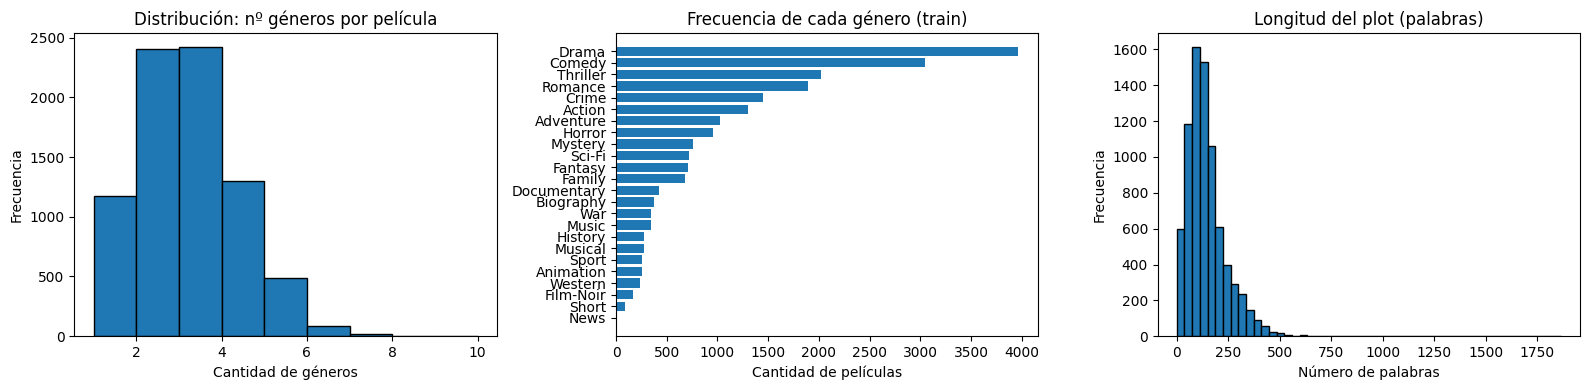


Longitud media del plot: 145 palabras
Total películas en training: 7895

Géneros disponibles (24):
      genre  count
      Drama   3965
     Comedy   3046
   Thriller   2024
    Romance   1892
      Crime   1447
     Action   1303
  Adventure   1024
     Horror    954
    Mystery    759
     Sci-Fi    723
    Fantasy    707
     Family    682
Documentary    419
  Biography    373
        War    348
      Music    341
    History    273
    Musical    271
      Sport    261
  Animation    260
    Western    237
  Film-Noir    168
      Short     92
       News      7


In [6]:
# Parsear géneros (necesario antes del EDA)
dataTraining['genres_list'] = dataTraining['genres'].map(lambda x: eval(x))

# --- Distribución: cantidad de géneros por película ---
genres_per_movie = dataTraining['genres_list'].map(len)
print("Géneros por película (estadísticas):")
print(genres_per_movie.describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(genres_per_movie, bins=range(1, genres_per_movie.max() + 2), edgecolor='black')
axes[0].set_title("Distribución: nº géneros por película")
axes[0].set_xlabel("Cantidad de géneros")
axes[0].set_ylabel("Frecuencia")

# --- Frecuencia de cada género ---
from collections import Counter
genre_counts = Counter(g for genres in dataTraining['genres_list'] for g in genres)
genre_df = pd.DataFrame(genre_counts.most_common(), columns=['genre', 'count'])
axes[1].barh(genre_df['genre'], genre_df['count'])
axes[1].set_title("Frecuencia de cada género (train)")
axes[1].set_xlabel("Cantidad de películas")
axes[1].invert_yaxis()

# --- Longitud del plot ---
plot_lengths = dataTraining['plot'].str.split().map(len)
axes[2].hist(plot_lengths, bins=50, edgecolor='black')
axes[2].set_title("Longitud del plot (palabras)")
axes[2].set_xlabel("Número de palabras")
axes[2].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

print(f"\nLongitud media del plot: {plot_lengths.mean():.0f} palabras")
print(f"Total películas en training: {len(dataTraining)}")
print(f"\nGéneros disponibles ({len(genre_df)}):")
print(genre_df.to_string(index=False))

## 2. Preprocesamiento de texto

Definimos una función `clean_text` que normaliza el plot antes de vectorizar: convierte a minúsculas, elimina HTML, dígitos y puntuación, y colapsa espacios extra.

In [7]:
def clean_text(text):
    """Limpieza básica del plot: HTML → lower → sin dígitos/puntuación → espacios colapsados."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', ' ', text)       # quitar etiquetas HTML
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)      # solo letras y espacios
    text = re.sub(r'\s+', ' ', text).strip()   # colapsar espacios
    return text

dataTraining['plot_clean'] = dataTraining['plot'].map(clean_text)
dataTesting['plot_clean']  = dataTesting['plot'].map(clean_text)

print("Ejemplo original :")
print(dataTraining['plot'].iloc[0][:200])
print("\nEjemplo limpio   :")
print(dataTraining['plot_clean'].iloc[0][:200])

Ejemplo original :
most is the story of a single father who takes his eight year - old son to work with him at the railroad drawbridge where he is the bridge tender .  a day before ,  the boy meets a woman boarding a tr

Ejemplo limpio   :
most is the story of a single father who takes his eight year old son to work with him at the railroad drawbridge where he is the bridge tender a day before the boy meets a woman boarding a train a dr


In [8]:
## 3. Variable objetivo multi-etiqueta

# genres_list ya fue parseada en el EDA; aquí la codificamos como matriz binaria
le = MultiLabelBinarizer()
y_genres = np.array(le.fit_transform(dataTraining['genres_list']))

cols = ['p_Action', 'p_Adventure', 'p_Animation', 'p_Biography', 'p_Comedy', 'p_Crime',
        'p_Documentary', 'p_Drama', 'p_Family', 'p_Fantasy', 'p_Film-Noir', 'p_History',
        'p_Horror', 'p_Music', 'p_Musical', 'p_Mystery', 'p_News', 'p_Romance',
        'p_Sci-Fi', 'p_Short', 'p_Sport', 'p_Thriller', 'p_War', 'p_Western']

# Verificar que el orden del binarizador coincide exactamente con el esperado por Kaggle
assert list(le.classes_) == [c[2:] for c in cols], \
    f"Orden de clases no coincide:\n{le.classes_}\nvs\n{[c[2:] for c in cols]}"
print("Clases confirmadas (en orden Kaggle):", list(le.classes_))
print("Matriz y_genres shape:", y_genres.shape)

Clases confirmadas (en orden Kaggle): ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War', 'Western']
Matriz y_genres shape: (7895, 24)


In [9]:
## 4. Vectorización TF-IDF (reemplaza CountVectorizer del baseline)
#
# Decisiones:
#   - ngram_range=(1,2): captura bigramas relevantes (p.ej. "serial killer", "time travel")
#   - sublinear_tf=True: aplica log(tf) → reduce el efecto de términos muy frecuentes
#   - max_features=50000: vocabulario suficientemente rico sin explotar memoria
#   - min_df=2: descarta tokens que aparecen en solo 1 documento (ruido)
#   - stop_words='english': elimina palabras vacías en inglés

vect = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
    sublinear_tf=True,
    stop_words='english',
)
X_dtm = vect.fit_transform(dataTraining['plot_clean'])
print("Matriz TF-IDF shape:", X_dtm.shape)

Matriz TF-IDF shape: (7895, 50000)


In [14]:
## 5. División train / validación (80/20)
#
# Nota: train_test_split no estratifica por combinación de etiquetas en multi-label.
# Para estratificación real se usaría iterative-stratification (mejora futura).

X_train, X_val, y_train_genres, y_val_genres = train_test_split(
    X_dtm, y_genres, test_size=0.20, random_state=42
)
print(f"Train: {X_train.shape[0]} muestras | Val: {X_val.shape[0]} muestras")

Train: 6316 muestras | Val: 1579 muestras


In [15]:
## 6. Modelo v1 — OneVsRest + LogisticRegression
#
# n_jobs=1 en OvR evita que joblib/loky pase los arrays por memory-map (read-only).
# liblinear es suficientemente rápido para 24 clasificadores binarios sobre TF-IDF sparse.

clf = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=1000, solver='liblinear'),
    n_jobs=1,
)
clf.fit(X_train, y_train_genres)
print(f"Modelo entrenado. {len(clf.estimators_)} clasificadores binarios (uno por género).")

ValueError: WRITEBACKIFCOPY base is read-only

In [ ]:
## 7. Evaluación — Modelo v1 (TF-IDF + LogReg)

y_pred_val = clf.predict_proba(X_val)

auc_macro_v1 = roc_auc_score(y_val_genres, y_pred_val, average='macro')
print(f"ROC AUC macro (v1 LogReg): {auc_macro_v1:.4f}")

# AUC por clase
auc_per_class = roc_auc_score(y_val_genres, y_pred_val, average=None)
auc_df = pd.DataFrame({'genre': le.classes_, 'AUC': auc_per_class}).sort_values('AUC')
print("\nAUC por género (de menor a mayor):")
print(auc_df.to_string(index=False))

# F1 con threshold por defecto 0.5
y_pred_binary = (y_pred_val >= 0.5).astype(int)
f1_macro = f1_score(y_val_genres, y_pred_binary, average='macro', zero_division=0)
f1_micro = f1_score(y_val_genres, y_pred_binary, average='micro', zero_division=0)
print(f"\nF1 macro (th=0.5): {f1_macro:.4f}")
print(f"F1 micro (th=0.5): {f1_micro:.4f}")

In [ ]:
## Comparación: Baseline RF (CountVectorizer 1k features) vs v1 (TF-IDF + LogReg)
#
# Reconstruimos los índices del mismo split (random_state=42, test_size=0.20)
# para evaluar el baseline sobre exactamente las mismas muestras.

idx_all = list(range(len(dataTraining)))
idx_train, idx_val = train_test_split(idx_all, test_size=0.20, random_state=42)

vect_base    = CountVectorizer(max_features=1000)
X_train_base = vect_base.fit_transform(dataTraining['plot_clean'].iloc[idx_train])
X_val_base   = vect_base.transform(dataTraining['plot_clean'].iloc[idx_val])
y_train_base = y_genres[idx_train].copy()
y_val_base   = y_genres[idx_val].copy()

clf_base = OneVsRestClassifier(
    RandomForestClassifier(n_jobs=1, n_estimators=100, max_depth=10, random_state=42)
)
clf_base.fit(X_train_base, y_train_base)
y_pred_base = clf_base.predict_proba(X_val_base)
auc_baseline = roc_auc_score(y_val_base, y_pred_base, average='macro')

print(f"ROC AUC macro — Baseline RF (CountVec 1k):  {auc_baseline:.4f}")
print(f"ROC AUC macro — v1 TF-IDF + LogReg       :  {auc_macro_v1:.4f}")
print(f"Mejora absoluta                            : +{auc_macro_v1 - auc_baseline:.4f}")

## 8. Re-entrenamiento con el 100% del training set

Antes de predecir el conjunto de test de Kaggle, re-entrenamos tanto el vectorizador como el clasificador usando **todas** las muestras de `dataTraining`, para no desperdiciar las muestras usadas como validación.

In [ ]:
# Re-fit del vectorizador y modelo sobre TODO el training set
vect_final = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=50000,
    sublinear_tf=True,
    stop_words='english',
)
X_full = vect_final.fit_transform(dataTraining['plot_clean'])

clf_final = OneVsRestClassifier(
    LogisticRegression(C=1.0, max_iter=1000, solver='liblinear'),
    n_jobs=1,
)
clf_final.fit(X_full, y_genres)
print("Re-entrenamiento completo. Features:", X_full.shape[1])

In [ ]:
## 9. Predicción sobre el conjunto de test (Kaggle)

# Transformar con el vectorizador re-entrenado sobre el 100% del training
X_test_dtm = vect_final.transform(dataTesting['plot_clean'])

# Predecir probabilidades (24 géneros)
y_pred_test_genres = clf_final.predict_proba(X_test_dtm)
print(f"Predicciones shape: {y_pred_test_genres.shape}")

In [ ]:
# Guardar predicciones en el formato requerido por Kaggle
res = pd.DataFrame(y_pred_test_genres, index=dataTesting.index, columns=cols)
res.to_csv('submission_tfidf_lr_v1.csv', index_label='ID')
print("Archivo guardado: submission_tfidf_lr_v1.csv")
res.head()

## 10. Persistencia de artefactos para la API (Semana 8)

Guardamos los cuatro artefactos que la API necesita cargar al arrancar, siguiendo el mismo patrón de `Semana 3/api.py`:
- `tfidf_vectorizer_v1.pkl` — transforma el plot crudo en vector TF-IDF.
- `genre_clf_v1.pkl` — modelo OvR que predice probabilidades por género.
- `mlb_genres_v1.pkl` — `MultiLabelBinarizer` para convertir índices → nombres de género.
- `output_columns_v1.pkl` — orden exacto de las 24 columnas de salida.

In [ ]:
joblib.dump(vect_final,   'tfidf_vectorizer_v1.pkl')
joblib.dump(clf_final,    'genre_clf_v1.pkl')
joblib.dump(le,           'mlb_genres_v1.pkl')
joblib.dump(cols,         'output_columns_v1.pkl')
print("Artefactos guardados:")
for f in ['tfidf_vectorizer_v1.pkl', 'genre_clf_v1.pkl', 'mlb_genres_v1.pkl', 'output_columns_v1.pkl']:
    import os
    size_mb = os.path.getsize(f) / 1e6 if os.path.exists(f) else 0
    print(f"  {f:35s} ({size_mb:.1f} MB)")